# 第 12 章 · 真实图片扩散加噪代码实验

本页用一张真实花朵照片观察扩散模型的前向过程。时间步越靠后，原图信号越弱、噪声越强，图像结构会逐渐被破坏。

[章节网页](../ch12.html)

## 运行内容

- 加载真实图片
- 按时间步加入噪声
- 绘制噪声调度

## 0. 图片加噪过程

先看调度表，再看图片序列。原图权重下降表示图像信号变弱，噪声权重上升表示随机噪声变强。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 真实图片扩散：按时间步逐渐加入噪声。
diffusion_packages = {
    "torch": "torch>=2.2",
    "diffusers": "diffusers>=0.30",
}
missing = [package for module, package in diffusion_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import torch
from diffusers import DDPMScheduler

ddpm_photo = Image.fromarray(load_sample_image("flower.jpg")).resize((128, 128))
ddpm_image = np.asarray(ddpm_photo).astype("float32") / 255.0
sample = torch.tensor(ddpm_image).permute(2, 0, 1).unsqueeze(0) * 2 - 1
torch.manual_seed(12)
noise = torch.randn(sample.shape)
scheduler = DDPMScheduler(num_train_timesteps=1000)
timesteps = [0, 100, 300, 600, 900]
ddpm_images = []
diff_rows = []

for t in timesteps:
    timestep = torch.tensor([t], dtype=torch.long)
    noisy = scheduler.add_noise(sample, noise, timestep)
    image = ((noisy[0].permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)
    ddpm_images.append(image)
    alpha_bar = float(scheduler.alphas_cumprod[t])
    diff_rows.append({
        "时间步": t,
        "alpha_bar": alpha_bar,
        "原图权重": np.sqrt(alpha_bar),
        "噪声权重": np.sqrt(1 - alpha_bar),
        "像素标准差": float(image.std()),
    })

diff_1d_df = pd.DataFrame(diff_rows)
display(diff_1d_df.round(4))

,时间步,alpha_bar,原图权重,噪声权重,像素标准差
0,0,0.9999,0.9999,0.0100,0.2373
1,100,0.8951,0.9461,0.3238,0.2501
2,300,0.3940,0.6277,0.7785,0.3211
3,600,0.0256,0.1599,0.9871,0.3568
4,900,0.0003,0.0164,0.9999,0.3588


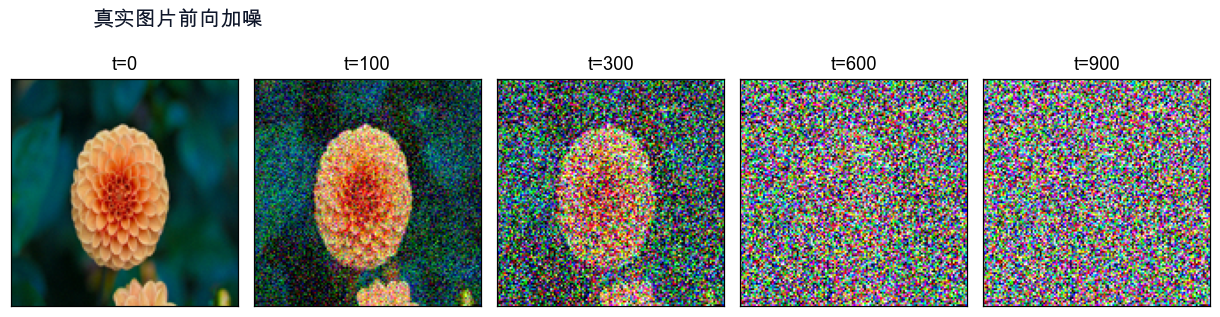

In [3]:
# 绘制真实图片在不同时间步下的前向扩散效果。
fig, axes = plt.subplots(1, len(ddpm_images), figsize=(11.2, 3.1))
for ax, image, timestep in zip(axes, ddpm_images, timesteps):
    ax.imshow(image)
    ax.set_title(f"t={timestep}", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("真实图片前向加噪", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()